In [1]:
%load_ext autoreload
%autoreload 2

# THIS NEEDS TO BE UPDATED WITH THE CHANGE FROM `read_dict` TO `InputTrajectories`.

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [4]:
import sys
sys.path.append(working_directory)

import os
import networkx as nx
from sctram.input import *

In [23]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [57]:
def plot_input_trajectories_multigraph(input_trajectories):
    plt.figure(figsize=(4,3))
    pos = nx.spring_layout(input_trajectories)  # positions for all nodes

    # nodes
    nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)

    # edges
    for u, v, key, data in input_trajectories.edges(data=True, keys=True):
        nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
        # label = {(u, v): data.get('distance', '')}
        # nx.draw_networkx_edge_labels(input_trajectories, pos, edge_labels=label, font_size=8)

    # labels
    nx.draw_networkx_labels(input_trajectories, pos, font_size=10)

    plt.axis("off")  # turn off the axis
    plt.tight_layout()
    plt.show()

def print_multidigraph_details(G):
    print("Graph Information:")
    print(G)
    
    print("\nNodes and Attributes:")
    for node, attrs in G.nodes(data=True):
        print(f"{node}: {attrs}")
    
    print("\nEdges and Attributes:")
    for u, v, key, data in G.edges(data=True, keys=True):
        print(f"{u} -> {v} key={key}: {data}")

# Input Module Guide

This guide provides an in-depth explanation of how to use the provided codebase to input trajectories using the `read_dict` function, detailing the acceptable input formats, internal processing, and how the input is transformed into graph structures. 

**Overview**

The codebase is designed to:

- Accept trajectory data in specific formats.
- Validate and process the input data.
- Construct graph representations of the trajectories using NetworkX.
- Provide utilities to extract individual trajectories and verify the graph’s integrity.

The primary function you’ll interact with is `read_dict`, which processes the input data and returns an InputTrajectories object—a specialized graph structure representing the trajectories.

## Input Data Structures

The `ground_truth_trajectories` parameter accepts a dictionary where each key represents a trajectory identifier (a string), and the value is an iterable of tuples representing edges in the trajectory.

Acceptable Tuple Formats:

1.	Without Edge Attributes:
    ```python
    ("start_node", "end_node")
    ```

2.	With Edge Attributes:
    ```python
    ("start_node", "end_node", {"attr_key": "attr_value", ...})
    ```

3.	With None as Edge Attributes:
    ```python
    ("start_node", "end_node", None)
    ```

### Example Input Formats

**Minimal Example (Tuples with Two Elements)**
```python
ground_truth_trajectories = {
    "trajectory_1": [
        ("node_A", "node_B"),
        ("node_B", "node_C"),
    ],
    "trajectory_2": [
        ("node_D", "node_E"),
    ],
}
```

**With Edge Attributes**
```python
ground_truth_trajectories = {
    "trajectory_1": [
        ("node_A", "node_B", {"weight": 1.5}),
        ("node_B", "node_C", {"weight": 2.0}),
    ],
    "trajectory_2": [
        ("node_D", "node_E", {"weight": 1.0}),
    ],
}
```

**Mixed Formats**
```python
ground_truth_trajectories = {
    "trajectory_1": [
        ("node_A", "node_B"),
        ("node_B", "node_C", {"weight": 2.0}),
    ],
    "trajectory_2": [
        ("node_D", "node_E", None),
    ],
}
```

### Additional Parameters


`additional_nodes` (Optional): An iterable of node identifiers (strings) to be added to the graph without connecting edges.
```python
additional_nodes = ["node_F", "node_G"]
```

`node_attributes` (Optional): A dictionary mapping node identifiers to their attributes.
```python
node_attributes = {
    "node_A": {"type": "sensor"},
    "node_F": {"type": "actuator"},
}
```

## Using the `read_dict` Function

**Function Signature**
```python
def read_dict(
    ground_truth_trajectories: InputGraphPossibleTypes,
    additional_nodes: Optional[Iterable[str]] = None,
    node_attributes: Optional[dict[str, dict[str, Any]]] = None,
) -> InputTrajectories:
    ...
```

**Steps to Use `read_dict`**
1. Prepare the `ground_truth_trajectories` input as per the acceptable formats.
2.	Optionally, prepare `additional_nodes` and `node_attributes` if needed.
3.	Call the `read_dict` function with the prepared inputs.
4.	Obtain an `InputTrajectories` object, which is a NetworkX graph with added functionalities.

**Example Usage**

In [31]:
# Prepare ground truth trajectories
ground_truth_trajectories = {
    "trajectory_1": [
        ("node_A", "node_B"),
        ("node_B", "node_C", {"distance": 5}),
    ],
    "trajectory_2": [
        ("node_D", "node_E", {"distance": 3}),
    ],
}

# Additional nodes
additional_nodes = ["node_F"]

# Node attributes
node_attributes = {
    "node_A": {"sensor": True},
    "node_D": {"sensor": False},
}

# Read the trajectories
input_trajectories = read_dict(
    ground_truth_trajectories=ground_truth_trajectories,
    additional_nodes=additional_nodes,
    node_attributes=node_attributes,
)

Edge (node_A, node_B) is missing attribute keys: {'distance'}
Node node_B is missing attribute keys: {'sensor'}
Node node_C is missing attribute keys: {'sensor'}
Node node_E is missing attribute keys: {'sensor'}
Node node_F is missing attribute keys: {'sensor'}


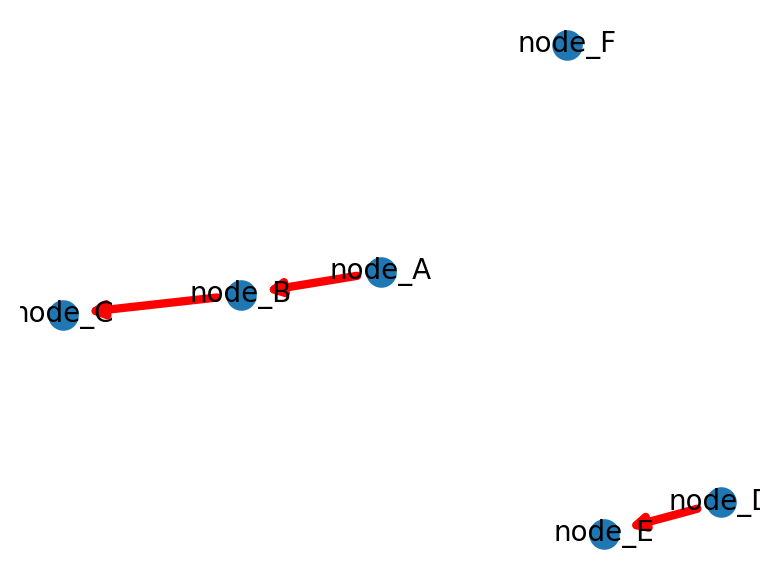

In [36]:
plot_input_trajectories_multigraph(input_trajectories)

### Internal Processing in read

#### Validation Functions

The read function utilizes several validation functions to ensure the input data adheres to expected formats:

-	`is_valid_input_structure`: Validates the structure of `ground_truth_trajectories`.
-	`is_valid_edge_attributes`: Checks for invalid edge attributes and self-loops.
-	`is_valid_node_attributes_structure`: Validates the structure of `node_attributes`.
-	`is_valid_additional_nodes`: Ensures that `additional_nodes` contain unique elements.

If any validation fails, a `ValueError` is raised with an appropriate error message.

#### Data Transformation Steps

1. Standardizing Edge Tuples: Converts all edge tuples to have exactly three elements, ensuring the third element is a dictionary (empty if not provided).
   ```python
   # Example transformation
    ("node_A", "node_B")  # becomes ("node_A", "node_B", {})
    ("node_C", "node_D", None)  # becomes ("node_C", "node_D", {})
   ```
2.	Initializing the Graph: Creates an `InputTrajectories` object, which is a subclass of `nx.MultiDiGraph`.
3.	Adding Edges: Iterates over each trajectory and adds edges to the graph. Each edge’s attributes include:
    -	The original attributes from the input.
    -	A reserved key `key_trajectories` indicating the trajectory it belongs to.
4.	Adding Nodes: Nodes connected by edges are automatically added. If `additional_nodes` is provided, these nodes are added without edges.
5.	Assigning Node Attributes:
    -	Nodes inherit attributes from `node_attributes` if provided.
    -	Each node’s `key_trajectories` attribute is a list of trajectories it is part of.
6.	Attribute Consistency Check:
    -	Ensures all edges and nodes have consistent attributes.
    -	Missing attributes are set to None.
    -	Warnings are logged for missing attributes.
7.	Verification:
    -	Calls the verify method to perform additional checks.
    -	Ensures individual trajectories are directed, acyclic, and do not contain self-loops.

## Graph Structure

1. Graph-Level Attributes:
   - `key_trajectories`: A sorted list of all trajectory identifiers.
2. Node Attributes:
   - `key_trajectories`: None if the node is an additional node; otherwise, a list of trajectories the node is part of.
   - Other attributes as provided in `node_attributes`.
3. Edge Attributes:
   - `key_trajectories`: The trajectory identifier the edge belongs to.
   - Other attributes as provided in `ground_truth_trajectories`.

#### Extracting Individual Trajectories

The `InputTrajectories` object provides a method `get_trajectory` to extract individual trajectories as subgraphs.

**Method Signature**
```python
def get_trajectory(self, trajectory: str, include_additional_nodes: bool) -> InputTrajectory:
    ...
```

- `trajectory`: The identifier of the trajectory to extract.
- `include_additional_nodes`: If True, includes additional nodes not connected by edges in the trajectory.

**Example Usage**

In [37]:
# Extract a single trajectory
trajectory_1 = input_trajectories.get_trajectory(
    trajectory="trajectory_1",
    include_additional_nodes=False
)

# Now, trajectory_1 is an InputTrajectory object (a subclass of nx.DiGraph)

**Notes**

- The extracted trajectory is a directed graph (nx.DiGraph).
- Edge and node attributes are preserved, except for the key_trajectories attribute, which is removed.
- Graph-level attributes are copied from the original graph, with key_trajectories set to the specific trajectory.

# Advanced Examples


Example 1: Multiple Trajectories with Edge Attributes

In [51]:
ground_truth_trajectories = {
    "traj_A": [
        ("sensor_1", "sensor_2", {"time": 10}),
        ("sensor_2", "sensor_3", {"time": 15}),
    ],
    "traj_B": [
        ("sensor_4", "sensor_5", {"time": 5}),
        ("sensor_5", "sensor_6", {"time": 20}),
    ],
}

node_attributes = {
    "sensor_1": {"location": "room_1"},
    "sensor_2": {"location": "room_2"},
    "sensor_3": {"location": "room_3"},
    "sensor_4": {"location": "room_4"},
    "sensor_5": {"location": "room_5"},
    "sensor_6": {"location": "room_6"},
}

input_trajectories = read_dict(
    ground_truth_trajectories=ground_truth_trajectories,
    node_attributes=node_attributes,
)

# Extracting a trajectory
traj_A_graph = input_trajectories.get_trajectory("traj_A", include_additional_nodes=False)

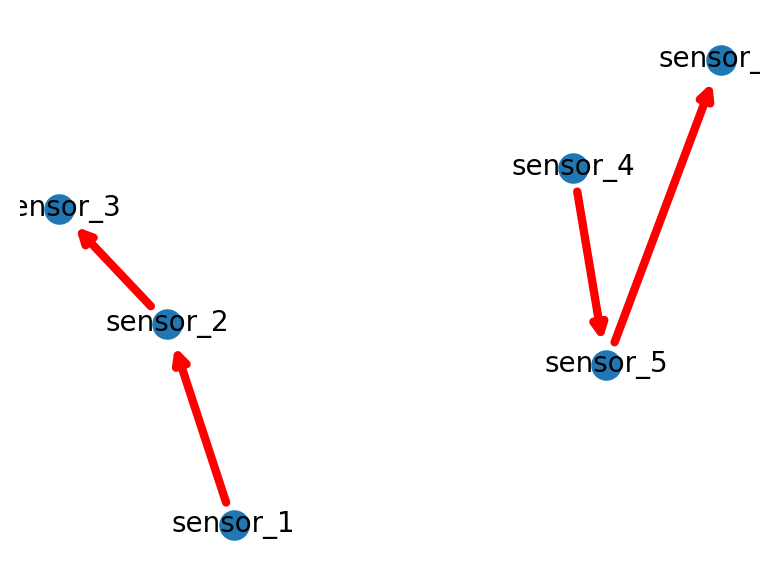

Graph Information:
InputTrajectories with 6 nodes and 4 edges

Nodes and Attributes:
sensor_1: {'trajectories': ['traj_A'], 'location': 'room_1'}
sensor_2: {'trajectories': ['traj_A'], 'location': 'room_2'}
sensor_3: {'trajectories': ['traj_A'], 'location': 'room_3'}
sensor_4: {'trajectories': ['traj_B'], 'location': 'room_4'}
sensor_5: {'trajectories': ['traj_B'], 'location': 'room_5'}
sensor_6: {'trajectories': ['traj_B'], 'location': 'room_6'}

Edges and Attributes:
sensor_1 -> sensor_2 key=0: {'time': 10, 'trajectories': 'traj_A'}
sensor_2 -> sensor_3 key=0: {'time': 15, 'trajectories': 'traj_A'}
sensor_4 -> sensor_5 key=0: {'time': 5, 'trajectories': 'traj_B'}
sensor_5 -> sensor_6 key=0: {'time': 20, 'trajectories': 'traj_B'}


In [58]:
plot_input_trajectories_multigraph(input_trajectories)
print_multidigraph_details(input_trajectories)

Example 2: Including Additional Nodes

In [59]:
ground_truth_trajectories = {
    "trajectory_main": [
        ("node_start", "node_middle"),
        ("node_middle", "node_end"),
    ],
}

additional_nodes = ["node_isolated"]

input_trajectories = read_dict(
    ground_truth_trajectories=ground_truth_trajectories,
    additional_nodes=additional_nodes,
)

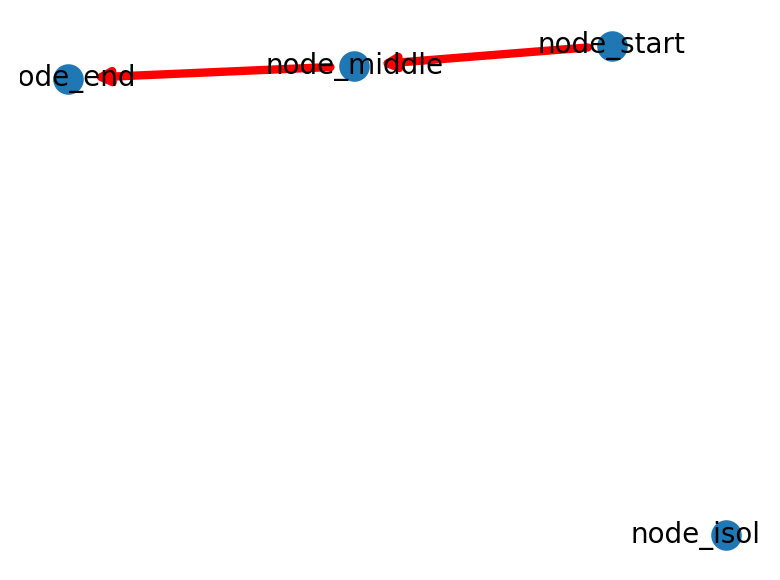

Graph Information:
InputTrajectories with 4 nodes and 2 edges

Nodes and Attributes:
node_start: {'trajectories': ['trajectory_main']}
node_middle: {'trajectories': ['trajectory_main']}
node_end: {'trajectories': ['trajectory_main']}
node_isolated: {'trajectories': None}

Edges and Attributes:
node_start -> node_middle key=0: {'trajectories': 'trajectory_main'}
node_middle -> node_end key=0: {'trajectories': 'trajectory_main'}


In [60]:
plot_input_trajectories_multigraph(input_trajectories)
print_multidigraph_details(input_trajectories)

Example 3: Complex Edge and Node Attributes

In [ ]:
ground_truth_trajectories = {
    "path_1": [
        ("A", "B", {"distance": 5, "speed_limit": 60}),
        ("B", "C", {"distance": 7, "speed_limit": 50}),
    ],
    "path_2": [
        ("D", "E", {"distance": 3, "speed_limit": 30}),
        ("E", "F", {"distance": 4, "speed_limit": 40}),
    ],
}

node_attributes = {
    "A": {"elevation": 100},
    "B": {"elevation": 150},
    "C": {"elevation": 200},
    "D": {"elevation": 50},
    "E": {"elevation": 80},
    "F": {"elevation": 120},
}

additional_nodes = ["G", "H"]

input_trajectories = InputTrajectories(
    ground_truth_trajectories=ground_truth_trajectories,
    node_attributes=node_attributes,
    additional_nodes=additional_nodes,
)

# Verify the graph
input_trajectories.verify()

# Extract individual paths
path_1_graph = input_trajectories.get_trajectory("path_1", include_additional_nodes=True)

Node G is missing attribute keys: {'elevation'}
Node H is missing attribute keys: {'elevation'}


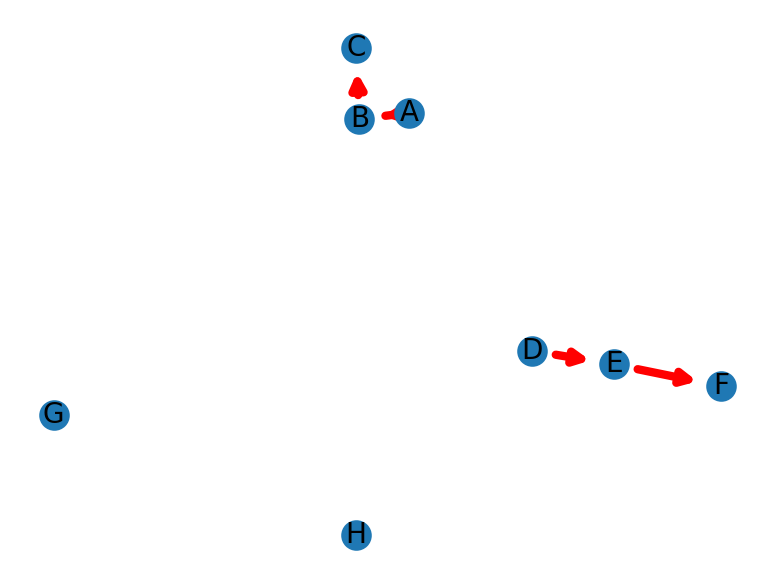

Graph Information:
InputTrajectories with 8 nodes and 4 edges

Nodes and Attributes:
A: {'trajectories': ['path_1'], 'elevation': 100}
B: {'trajectories': ['path_1'], 'elevation': 150}
C: {'trajectories': ['path_1'], 'elevation': 200}
D: {'trajectories': ['path_2'], 'elevation': 50}
E: {'trajectories': ['path_2'], 'elevation': 80}
F: {'trajectories': ['path_2'], 'elevation': 120}
G: {'trajectories': None, 'elevation': None}
H: {'trajectories': None, 'elevation': None}

Edges and Attributes:
A -> B key=0: {'distance': 5, 'speed_limit': 60, 'trajectories': 'path_1'}
B -> C key=0: {'distance': 7, 'speed_limit': 50, 'trajectories': 'path_1'}
D -> E key=0: {'distance': 3, 'speed_limit': 30, 'trajectories': 'path_2'}
E -> F key=0: {'distance': 4, 'speed_limit': 40, 'trajectories': 'path_2'}


In [62]:
plot_input_trajectories_multigraph(input_trajectories)
print_multidigraph_details(input_trajectories)

# Important Considerations


-   Reserved Keys:
    - key_trajectories is a reserved key used internally. Do not use this key in your edge or node attributes.
-	Self-Loops and Multigraphs:
    -	Self-loops are not allowed; an edge cannot start and end at the same node.
    -	Individual trajectories must not be multigraphs. Multiple edges between the same pair of nodes in the same trajectory are not permitted.
-	Attribute Consistency:
    -	The code ensures that all nodes and edges have the same set of attributes.
    -	Missing attributes are filled with None, and a warning is logged.
-	Node and Edge Identifiers:
    -	Node identifiers must be strings.
    -	Edge attributes (when provided) must be dictionaries or None.

**Conclusion**

By following this guide, you should be able to:

-	Prepare trajectory data in the accepted formats.
-	Use the read function to process and validate your input data.
-	Understand how the input data is transformed into graph structures.
-	Extract and analyze individual trajectories as subgraphs.